Mounted at /content/drive

Found 25 files. Processing data...

=== Arousal (Pupil Instability) Numerical Results ===

ASD Average Pupil Instability (Change per 250ms): 0.06349 mm
TD Average Pupil Instability (Change per 250ms): 0.04915 mm

=> Result: The ASD group shows HIGHER fluctuation frequency (higher arousal).
   Difference: 0.01435 mm

Generating Group Average Instability Graph...


/tmp/ipykernel_21448/1844627842.py:131: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


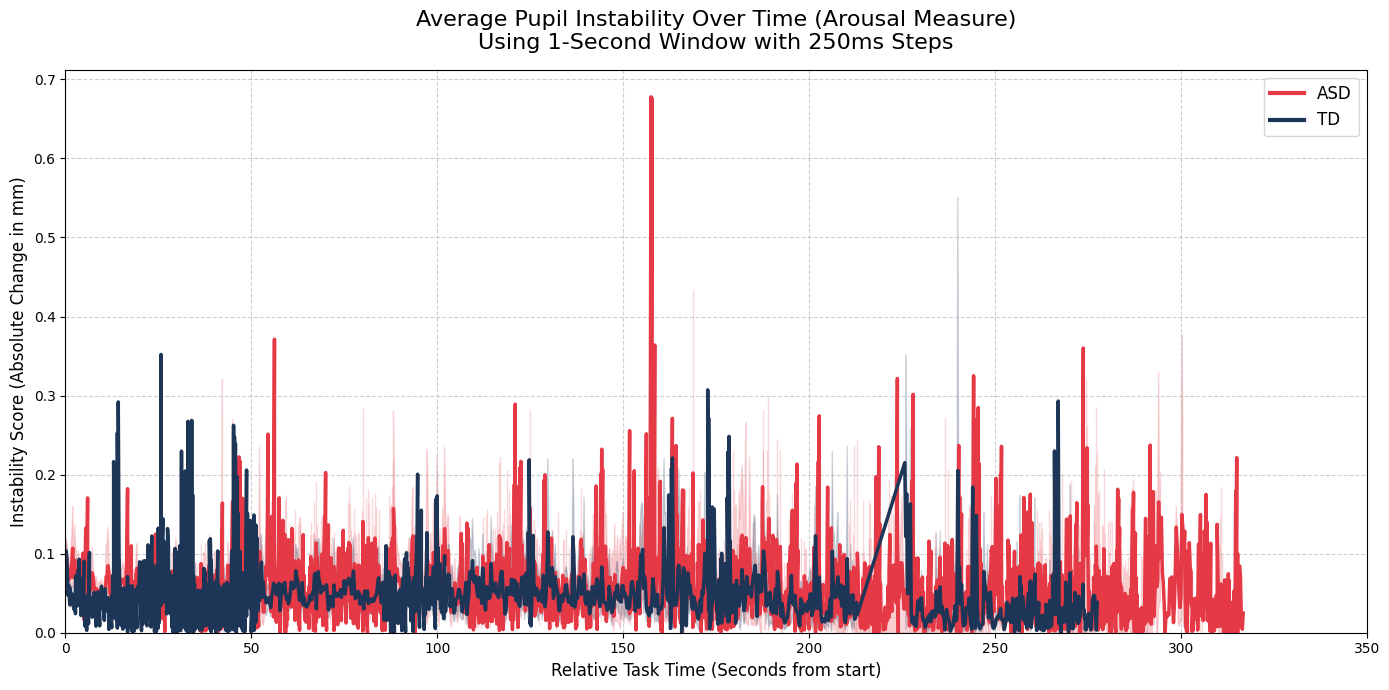

In [ ]:
# Imports used for loading files, working with data, and plotting
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive so the csv files can be accessed
from google.colab import drive
drive.mount('/content/drive')

# Main column names used in the analysis
pupil_col = 'Pupil Diameter Right [mm]'
columns_to_use = ['Participant', 'RecordingTime [ms]', pupil_col, 'Category Right']

# Path to the eye-tracking csv files
path = "/content/drive/MyDrive/Eye-tracking Output/*.csv"
allCsv = glob.glob(path)

MICRO_WINDOW_MS = 1000  # Window size of 1 second
STEP_MS = 250           # Move the window every 250 ms
MAX_TIME_MS = 500000    # Use only the first 500 seconds for a clearer graph

print(f"\nFound {len(allCsv)} files. Processing data...")

# Stores the window-based instability results for all participants
all_windows_data = []

# Go over each csv file and calculate pupil instability per participant
for csv_file in allCsv:
    df = pd.read_csv(csv_file, dtype=str, low_memory=False)

    # Skip files that do not contain the needed columns
    if not all(col in df.columns for col in columns_to_use):
        continue

    # Convert time and pupil diameter columns to numeric values
    df['RecordingTime [ms]'] = pd.to_numeric(df['RecordingTime [ms]'], errors='coerce')
    df[pupil_col] = pd.to_numeric(df[pupil_col], errors='coerce')

    # Remove rows with missing time or pupil values, and remove blink samples
    df = df.dropna(subset=['RecordingTime [ms]', pupil_col])
    if 'Category Right' in df.columns:
        df = df[df['Category Right'].str.lower() != 'blink']

    # Analyze each participant separately
    for participant_id, p_df in df.groupby("Participant"):
        if not str(participant_id).isdigit():
            continue

        pid = int(participant_id)

        # Assign the participant to ASD or TD according to the dataset IDs
        if 1 <= pid <= 29:
            group = 'ASD'
        elif 30 <= pid <= 59:
            group = 'TD'
        else:
            continue

        p_df = p_df.sort_values('RecordingTime [ms]')
        start_time = p_df['RecordingTime [ms]'].min()
        end_time = p_df['RecordingTime [ms]'].max()

        current_start = start_time
        prev_mean = None  # Mean pupil value of the previous window

        # Move over the recording using overlapping time windows
        while (current_start + MICRO_WINDOW_MS <= end_time) and ((current_start - start_time) <= MAX_TIME_MS):
            current_end = current_start + MICRO_WINDOW_MS
            w_df = p_df[(p_df['RecordingTime [ms]'] >= current_start) & (p_df['RecordingTime [ms]'] < current_end)]

            # Use the window only if it has enough valid samples
            if len(w_df) >= 5 and w_df[pupil_col].notna().any():
                curr_mean = w_df[pupil_col].dropna().mean()

                # Instability is the absolute change from the previous window
                if prev_mean is not None:
                    instability = abs(curr_mean - prev_mean)
                    relative_time_sec = (current_start - start_time) / 1000.0

                    all_windows_data.append({
                        'Participant': pid,
                        'Group': group,
                        'RelativeTime_Sec': relative_time_sec,
                        'Instability_Score': instability
                    })

                prev_mean = curr_mean
            else:
                # Reset after missing data so large gaps will not create false changes
                prev_mean = None

            current_start += STEP_MS

# Create one dataframe with all calculated windows
plot_df = pd.DataFrame(all_windows_data)

print("\n============================================================")
print("=== Arousal (Pupil Instability) Numerical Results ===")
print("============================================================\n")

if plot_df.empty:
    print("No valid data was extracted. Check column names and paths.")
else:
    # Calculate the average instability score for each group
    numeric_instability = plot_df.groupby('Group')['Instability_Score'].mean()

    asd_instability = numeric_instability.get('ASD', 0)
    td_instability = numeric_instability.get('TD', 0)

    print(f"ASD Average Pupil Instability (Change per 250ms): {asd_instability:.5f} mm")
    print(f"TD Average Pupil Instability (Change per 250ms): {td_instability:.5f} mm")

    if asd_instability > td_instability:
        print(f"\n=> Result: The ASD group shows HIGHER fluctuation frequency (higher arousal).")
        print(f"   Difference: {(asd_instability - td_instability):.5f} mm")
    elif td_instability > asd_instability:
        print(f"\n=> Result: The TD group shows HIGHER fluctuation frequency (higher arousal).")
        print(f"   Difference: {(td_instability - asd_instability):.5f} mm")
    else:
        print("\n=> Result: Both groups show the same level of fluctuation.")

    print("============================================================\n")

    print("Generating Group Average Instability Graph...")

    plt.figure(figsize=(14, 7))

    # Plot the average instability over time for ASD and TD groups
    sns.lineplot(
        data=plot_df,
        x='RelativeTime_Sec',
        y='Instability_Score',
        hue='Group',
        palette={'ASD': '#E63946', 'TD': '#1D3557'},
        linewidth=2.5,
        ci=95  # 95% confidence interval
    )

    plt.title("Average Pupil Instability Over Time (Arousal Measure)\nUsing 1-Second Window with 250ms Steps", fontsize=16, pad=15)
    plt.xlabel("Relative Task Time (Seconds from start)", fontsize=12)
    plt.ylabel("Instability Score (Absolute Change in mm)", fontsize=12)

    # Basic graph formatting
    plt.xlim(0, 350)
    plt.ylim(bottom=0)
    plt.grid(True, linestyle='--', alpha=0.6)

    leg = plt.legend(loc='upper right', fontsize=12)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    plt.tight_layout()
    plt.show()

Mounted at /content/drive
Extracting Exploration, Exploitation, and Pupil features (Participant Level)...

Dataset ready! Total Participants: 57

=== Feature Group Testing (Ablation Study) ===

[ Evaluating: 1. Exploration & Exploitation Only ]
  Best Params Found: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
  Average CV Accuracy: 75.76%

  Classification Report:
                  precision    recall  f1-score   support
    
              TD       0.75      0.80      0.77        30
             ASD       0.76      0.70      0.73        27
    
        accuracy                           0.75        57
       macro avg       0.76      0.75      0.75        57
    weighted avg       0.75      0.75      0.75        57
    

[ Evaluating: 2. Pupil Dynamics Only ]
  Best Params Found: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 50}
  Average CV Accuracy: 70.15%

  Classif

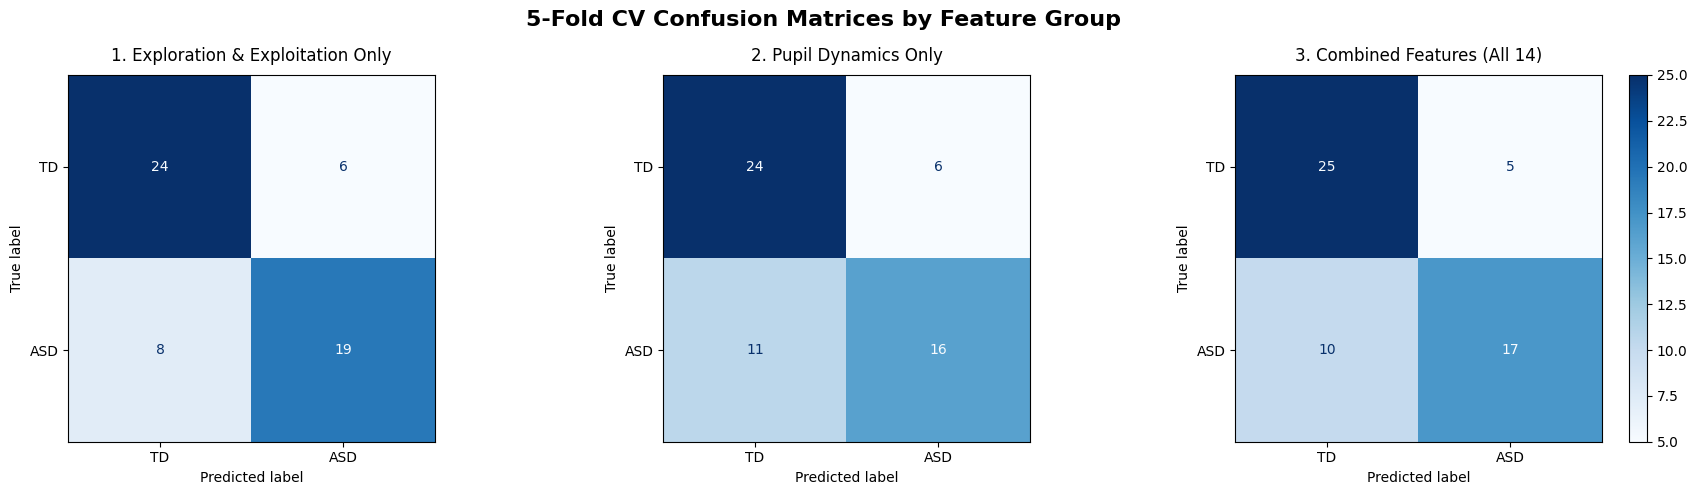


=== Global Feature Importance - Combined Model ===

Feature importance ranking:

              Feature Importance
            Std Pupil   0.095109
       Total AOI Time   0.049706
    Saccade Frequency   0.034710
Avg Fixation Duration   0.032848
      Gaze Dispersion   0.030413
             Pupil CV   0.030200
          Pupil Range   0.027934
       Fixation Pupil   0.027391
            Max Pupil   0.025884
            Avg Pupil   0.025329
       Pupil Velocity   0.025320
   Avg Saccade Length   0.016067
Max Fixation Duration   0.012518
          AOI Changes   0.004986


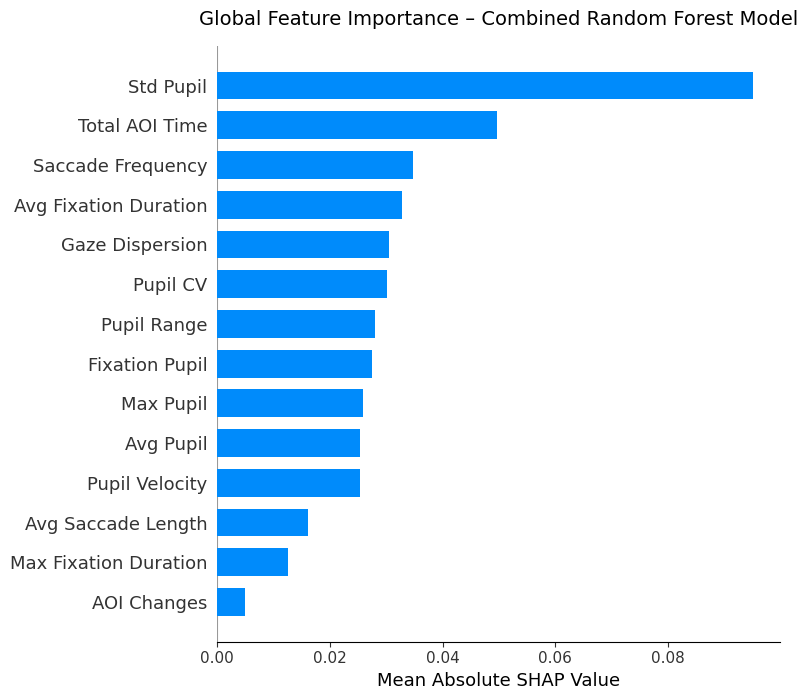


=== Feature Patterns (ASD vs. TD Averages) ===

[ ALL FEATURES COMBINED ]
Diagnosis                   ASD        TD  Difference (ASD - TD)
Avg Fixation Duration  408.5544  465.6446               -57.0902
Max Fixation Duration 3051.9264 2632.2832               419.6432
Total AOI Time        2143.1111 3200.6333             -1057.5222
Saccade Frequency        1.2661    1.6244                -0.3583
Avg Saccade Length     284.4907  288.7940                -4.3033
AOI Changes            102.1852  121.1333               -18.9481
Gaze Dispersion        319.8812  272.0366                47.8446
Avg Pupil                4.0547    3.6422                 0.4125
Max Pupil                5.3443    4.5273                 0.8170
Std Pupil                0.3839    0.3595                 0.0244
Pupil CV                 0.0959    0.0970                -0.0011
Pupil Range              3.2200    2.4565                 0.7635
Pupil Velocity           3.8783    5.1453                -1.2669
Fixation Pupil 

In [ ]:
# Imports for reading the csv files, handling the data, and plotting results
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Connect to Google Drive to load the eye-tracking files
from google.colab import drive
drive.mount('/content/drive')

# Columns that are needed from the files
columns_to_use = [
    'Participant', 'RecordingTime [ms]', 'Category Right',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]'
]
pupil_col = 'Pupil Diameter Right [mm]'
aoi_col = 'AOI Name Right'

# Folder path for all csv files
path = "/content/drive/MyDrive/Eye-tracking Output/*.csv"
allCsv = glob.glob(path)

participants_features = {}
labels = {}

print("Extracting Exploration, Exploitation, and Pupil features (Participant Level)...")

for csv_file in allCsv:
    df = pd.read_csv(csv_file, dtype=str, low_memory=False)

    if not all(col in df.columns for col in columns_to_use):
        print(f"Skipping {csv_file}, missing required column")
        continue

    df['RecordingTime [ms]'] = pd.to_numeric(df['RecordingTime [ms]'], errors='coerce')
    df['Point of Regard Right X [px]'] = pd.to_numeric(df['Point of Regard Right X [px]'], errors='coerce')
    df['Point of Regard Right Y [px]'] = pd.to_numeric(df['Point of Regard Right Y [px]'], errors='coerce')

    if pupil_col in df.columns:
        df[pupil_col] = pd.to_numeric(df[pupil_col], errors='coerce')
    else:
        df[pupil_col] = np.nan

    df = df.dropna(subset=['RecordingTime [ms]', 'Category Right'])
    df = df[df['Category Right'].str.lower() != 'blink']

    for participant_id, p_df in df.groupby("Participant"):
        if not str(participant_id).isdigit():
            continue

        pid = int(participant_id)

        # Set the label according to the participant number
        if 1 <= pid <= 29:
            y = 1
        elif 30 <= pid <= 59:
            y = 0
        else:
            continue

        p_df = p_df.sort_values('RecordingTime [ms]')
        p_df['Block'] = (p_df['Category Right'] != p_df['Category Right'].shift()).cumsum()

        block_durations = p_df.groupby(['Block', 'Category Right'])['RecordingTime [ms]'].agg(lambda x: x.max() - x.min()).reset_index()
        block_durations.rename(columns={'RecordingTime [ms]': 'Duration'}, inplace=True)

        # Features that describe focus on specific areas
        fixation_blocks = block_durations[block_durations['Category Right'] == 'Fixation']
        if not fixation_blocks.empty and fixation_blocks['Duration'].max() > 0:
            avg_fix_dur = fixation_blocks['Duration'].mean()
            max_fix_dur = fixation_blocks['Duration'].max()
        else:
            avg_fix_dur, max_fix_dur = 0, 0

        total_aoi_time = 0
        aoi_changes = 0
        if aoi_col in p_df.columns:
            valid_aoi_df = p_df.dropna(subset=[aoi_col])
            valid_aoi_df = valid_aoi_df[valid_aoi_df[aoi_col].str.strip() != ""]
            if not valid_aoi_df.empty:
                total_aoi_time = len(valid_aoi_df)
                aoi_changes = (valid_aoi_df[aoi_col] != valid_aoi_df[aoi_col].shift()).sum()

        # Features that describe scanning and eye movement
        saccade_blocks = block_durations[block_durations['Category Right'] == 'Saccade']
        total_time_sec = (p_df['RecordingTime [ms]'].max() - p_df['RecordingTime [ms]'].min()) / 1000.0
        saccade_freq = len(saccade_blocks) / total_time_sec if total_time_sec > 0 else 0

        saccade_lengths = []
        for block_id in saccade_blocks['Block']:
            s_df = p_df[p_df['Block'] == block_id].dropna(subset=['Point of Regard Right X [px]', 'Point of Regard Right Y [px]'])
            if len(s_df) >= 2:
                dx = s_df['Point of Regard Right X [px]'].iloc[-1] - s_df['Point of Regard Right X [px]'].iloc[0]
                dy = s_df['Point of Regard Right Y [px]'].iloc[-1] - s_df['Point of Regard Right Y [px]'].iloc[0]
                saccade_lengths.append(np.sqrt(dx**2 + dy**2))

        avg_saccade_len = np.mean(saccade_lengths) if saccade_lengths else 0
        std_x = p_df['Point of Regard Right X [px]'].std()
        std_y = p_df['Point of Regard Right Y [px]'].std()
        gaze_dispersion = np.sqrt(std_x**2 + std_y**2) if pd.notna(std_x) and pd.notna(std_y) else 0

        # Features based on changes in pupil diameter
        if p_df[pupil_col].notna().any():
            pupil_data = p_df[pupil_col].dropna()
            avg_pupil = pupil_data.mean()
            max_pupil = pupil_data.max()
            min_pupil = pupil_data.min()
            std_pupil = pupil_data.std()
            if pd.isna(std_pupil): std_pupil = 0

            pupil_cv = std_pupil / avg_pupil if avg_pupil > 0 else 0
            pupil_range = max_pupil - min_pupil

            time_data = p_df['RecordingTime [ms]'].loc[pupil_data.index]
            pupil_diff = pupil_data.diff().abs()
            time_diff = time_data.diff()
            velocity = (pupil_diff / time_diff.replace(0, np.nan)).mean() * 1000
            if pd.isna(velocity): velocity = 0

            fix_pupil = p_df.loc[p_df['Category Right'] == 'Fixation', pupil_col].mean()
            if pd.isna(fix_pupil): fix_pupil = avg_pupil
        else:
            avg_pupil, max_pupil, std_pupil = 0, 0, 0
            pupil_cv, pupil_range, velocity, fix_pupil = 0, 0, 0, 0

        # Save all the features calculated for this participant
        participants_features[pid] = [
            avg_fix_dur, max_fix_dur, total_aoi_time,
            saccade_freq, avg_saccade_len, aoi_changes, gaze_dispersion,
            avg_pupil, max_pupil, std_pupil, pupil_cv, pupil_range, velocity, fix_pupil
        ]
        labels[pid] = y

# Create X and y arrays for the model
X_list, y_list = [], []
for pid in sorted(participants_features.keys()):
    X_list.append(participants_features[pid])
    y_list.append(labels[pid])

X = np.nan_to_num(np.array(X_list))
y = np.array(y_list)

print(f"\nDataset ready! Total Participants: {X.shape[0]}")

print("\n============================================================")
print("=== Feature Group Testing (Ablation Study) ===")
print("============================================================")

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split the features into groups so we can test which type helps more
feature_sets = {
    "1. Exploration & Exploitation Only": X[:, 0:7],
    "2. Pupil Dynamics Only": X[:, 7:14],
    "3. Combined Features (All 14)": X
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
])

# Different model settings to test
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 5, 10],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

# Prepare one plot with confusion matrices for all feature groups
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("5-Fold CV Confusion Matrices by Feature Group", fontsize=16, fontweight='bold')

# Train and evaluate the model for each feature group
for i, (group_name, X_subset) in enumerate(feature_sets.items()):
    print(f"\n[ Evaluating: {group_name} ]")

    # Find the best Random Forest parameters for this group
    grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_subset, y)
    best_model = grid_search.best_estimator_
    # Save the final model that uses all 14 features
    if group_name == "3. Combined Features (All 14)":
        combined_best_model = best_model

    print(f"  Best Params Found: {grid_search.best_params_}")
    print(f"  Average CV Accuracy: {grid_search.best_score_ * 100:.2f}%")

    # Get predictions from cross validation
    cv_predictions = cross_val_predict(best_model, X_subset, y, cv=skf)

    # Print the model results
    print(f"\n  Classification Report:")
    report = classification_report(y, cv_predictions, target_names=["TD", "ASD"], zero_division=0)
    for line in report.split('\n'):
        print(f"    {line}")

    # Draw the confusion matrix for this feature group
    cm = confusion_matrix(y, cv_predictions)
    disp = ConfusionMatrixDisplay(cm, display_labels=["TD", "ASD"])

    # Add the colorbar only to the last plot so the figure is cleaner
    show_colorbar = True if i == 2 else False
    disp.plot(cmap=plt.cm.Blues, ax=axes[i], colorbar=show_colorbar)

    axes[i].set_title(group_name, pad=10)

# Show all confusion matrices together
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# ---------- Global Feature Importance Using SHAP ----------

# Install and import SHAP
!pip install shap -q
import shap

print("\n============================================================")
print("=== Global Feature Importance - Combined Model ===")
print("============================================================\n")

# Names must match the exact order of the 14 columns in X
feature_names = [
    "Avg Fixation Duration",
    "Max Fixation Duration",
    "Total AOI Time",
    "Saccade Frequency",
    "Avg Saccade Length",
    "AOI Changes",
    "Gaze Dispersion",
    "Avg Pupil",
    "Max Pupil",
    "Std Pupil",
    "Pupil CV",
    "Pupil Range",
    "Pupil Velocity",
    "Fixation Pupil"
]

# Apply the same scaling that was used during model training
X_scaled = combined_best_model.named_steps["scaler"].transform(X)

# Extract the Random Forest classifier from the pipeline
combined_classifier = combined_best_model.named_steps["clf"]

# Calculate SHAP values
explainer = shap.TreeExplainer(combined_classifier)
shap_values = explainer.shap_values(X_scaled)

# Handle differences between SHAP versions
if isinstance(shap_values, list):
    # Class 1 represents ASD
    shap_values_asd = shap_values[1]
else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Newer versions may return:
        # samples × features × classes
        if shap_array.shape[0] == X_scaled.shape[0]:
            shap_values_asd = shap_array[:, :, 1]

        # Some versions may return:
        # classes × samples × features
        else:
            shap_values_asd = shap_array[1]
    else:
        shap_values_asd = shap_array

# Calculate the average absolute SHAP value of every feature
mean_absolute_shap = np.abs(shap_values_asd).mean(axis=0)

# Create a sorted importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_absolute_shap
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Print the feature ranking
print("Feature importance ranking:\n")
print(
    importance_df.to_string(
        index=False,
        formatters={"Importance": "{:.6f}".format}
    )
)

# Draw a global SHAP importance graph
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_asd,
    X_scaled,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    "Global Feature Importance – Combined Random Forest Model",
    fontsize=14,
    pad=15
)
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

print("\n============================================================")
print("=== Feature Patterns (ASD vs. TD Averages) ===")
print("============================================================\n")

feature_names = [
    "Avg Fixation Duration", "Max Fixation Duration", "Total AOI Time",
    "Saccade Frequency", "Avg Saccade Length", "AOI Changes", "Gaze Dispersion",
    "Avg Pupil", "Max Pupil", "Std Pupil",
    "Pupil CV", "Pupil Range", "Pupil Velocity", "Fixation Pupil"
]

feature_categories = {
    "EXPLOITATION (Focus & Depth)": [
        "Avg Fixation Duration", "Max Fixation Duration", "Total AOI Time"
    ],
    "EXPLORATION (Scanning & Breadth)": [
        "Saccade Frequency", "Avg Saccade Length", "AOI Changes", "Gaze Dispersion"
    ],
    "PUPIL DYNAMICS (Cognitive Load & Arousal)": [
        "Avg Pupil", "Max Pupil", "Std Pupil",
        "Pupil CV", "Pupil Range", "Pupil Velocity", "Fixation Pupil"
    ]
}

pattern_df = pd.DataFrame(X, columns=feature_names)
pattern_df['Diagnosis'] = ['ASD' if label == 1 else 'TD' for label in y]

averages = pattern_df.groupby('Diagnosis').mean().T
averages['Difference (ASD - TD)'] = averages['ASD'] - averages['TD']

print("[ ALL FEATURES COMBINED ]")
print(averages.to_string(float_format="%.4f"))

print("\n============================================================")
print("=== Plain-English Pattern Breakdown (Categorized) ===")
print("============================================================")

for category_name, features_in_category in feature_categories.items():
    print(f"\n[ {category_name} ]")
    for feature in features_in_category:
        asd_avg = averages.loc[feature, 'ASD']
        td_avg = averages.loc[feature, 'TD']

        pct_diff = abs((asd_avg - td_avg) / td_avg) * 100 if td_avg != 0 else 0

        if asd_avg > td_avg:
            print(f"  ▲ {feature}: ASD generally had HIGHER values (+{pct_diff:.1f}% compared to TD).")
        elif asd_avg < td_avg:
            print(f"  ▼ {feature}: ASD generally had LOWER values (-{pct_diff:.1f}% compared to TD).")
        else:
            print(f"  = {feature}: Both groups had nearly identical averages.")